/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

/tmp/ipython-input-3319723999.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataset["train"]["label"], palette="viridis")


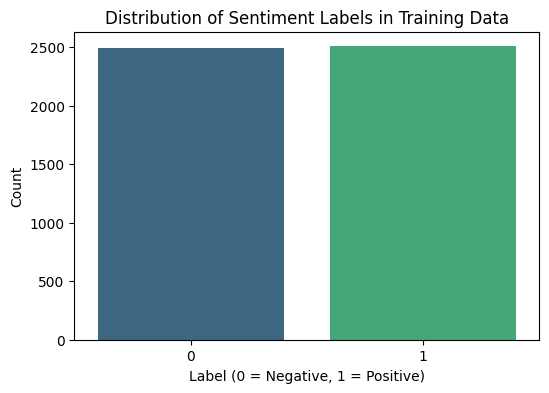

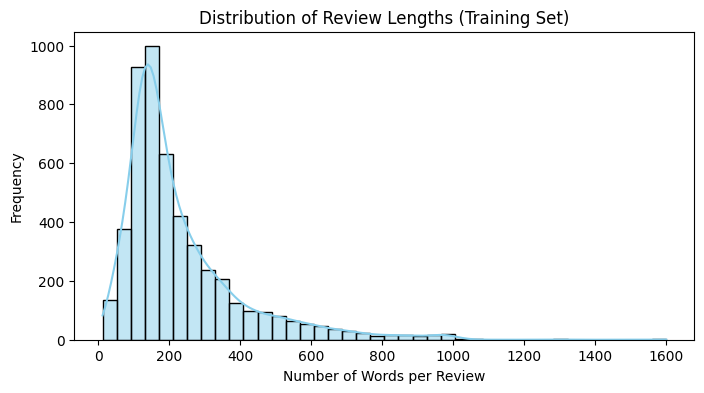

Average review length: 231.83 words


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3319723999.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rumman-khan053 (rumman-khan053-svkm-s-narsee-monjee-institute-of-managem) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
50,0.673500,0.605931,0.694500,0.597231,0.876209,0.453000
100,0.462700,0.379336,0.836500,0.842561,0.812442,0.875000
150,0.382400,0.378029,0.847500,0.834509,0.912218,0.769000
200,0.426500,0.350474,0.850000,0.839572,0.902299,0.785000
250,0.385800,0.353176,0.852000,0.860771,0.812611,0.915000
300,0.344600,0.309310,0.865000,0.867906,0.849617,0.887000
350,0.255400,0.340539,0.863500,0.863568,0.863137,0.864000
400,0.211400,0.389328,0.862500,0.858757,0.882788,0.836000
450,0.263000,0.418854,0.854500,0.845787,0.899662,0.798000
500,0.245800,0.338203,0.867500,0.867698,0.866401,0.869000


KeyboardInterrupt: 

In [ ]:
# Step 1: Install dependencies
!pip install transformers datasets torch scikit-learn

# Step 2: Import libraries
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Step 3: Load IMDb dataset
dataset = load_dataset("imdb")

# For speed in demo: use small subset (later use full dataset)
small_train = dataset["train"].shuffle(seed=42).select(range(5000))
small_test = dataset["test"].shuffle(seed=42).select(range(2000))

dataset = DatasetDict({
    "train": small_train,
    "test": small_test
})
# Step 3.1: Data Visualization – Label Distribution & Review Lengths
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot label distribution
plt.figure(figsize=(6,4))
sns.countplot(x=dataset["train"]["label"], palette="viridis")
plt.title("Distribution of Sentiment Labels in Training Data")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

# Plot review lengths
review_lengths = [len(text.split()) for text in dataset["train"]["text"]]
plt.figure(figsize=(8,4))
sns.histplot(review_lengths, bins=40, color="skyblue", kde=True)
plt.title("Distribution of Review Lengths (Training Set)")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.show()

print(f"Average review length: {np.mean(review_lengths):.2f} words")

# Step 4: Preprocess data (BERT tokenizer)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

encoded_dataset = dataset.map(preprocess_function, batched=True)

# Step 5: Load BERT model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Step 6: Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Step 7: Training setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps", # Changed from "epoch" to "steps"
    save_strategy="steps",
    save_steps=50,
    eval_steps=50, # Added eval_steps to match save_steps
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

#  Step 8: Train BERT
trainer.train()

# 🚀 Step 9: Evaluate BERT
results = trainer.evaluate()
print(results)

# Step 10: Visualize Training and Evaluation Loss
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
train_loss = logs[logs["loss"].notnull()]
eval_loss = logs[logs["eval_loss"].notnull()]

plt.figure(figsize=(8,5))
plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss", color="blue")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Evaluation Loss", color="red")
plt.title("Training vs Evaluation Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()
# Step 11: Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = trainer.predict(encoded_dataset["test"])
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix for BERT Sentiment Classification")
plt.show()

# Step 12: Sample Predictions
import random

for i in random.sample(range(len(dataset["test"])), 5):
    text = dataset["test"][i]["text"][:300] + "..."
    true_label = dataset["test"][i]["label"]
    pred_label = int(y_pred[i])
    print(f"\nReview: {text}")
    print(f"Actual Label: {'Positive' if true_label else 'Negative'}")
    print(f"Predicted Label: {'Positive' if pred_label else 'Negative'}")
